## sentiment analysis

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [2]:
#Load Dataset
from tensorflow.keras.datasets import imdb

(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=10000)

In [3]:
#Explore Dataset
print(X_train.shape)

(25000,)


In [4]:
print(y_train.shape)

(25000,)


In [5]:
print(len(X_train[0]))

218


In [6]:
#padding 
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length=200

X_train=pad_sequences(
    X_train,
    maxlen=max_length
)

X_test=pad_sequences(
    X_test,
    maxlen=max_length
)

In [7]:
#GRU Model
model=Sequential()

In [8]:
#Embedding layer 
#layer 1
model.add(
    Embedding(
        input_dim=10000,
        output_dim=64,
        input_length=max_length
    )
)

d:\Deep-learning-revision-\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
# layer 2
model.add(
    GRU(
        32,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)

In [10]:
# Layer 3
model.add(
    Dropout(0.5)
)

In [11]:
#Dense here add a regularizer to prevent overfitting
#Layer 4
from tensorflow.keras.regularizers import l2
model.add(
    Dense(
        32,
        activation='relu',
        kernel_regularizer=l2(0.006)
    )
)

In [12]:
# layer 5
model.add(
    Dropout(0.5)
)

In [13]:
# Layer 6
model.add(
    Dense(
        16,
        activation='relu'
    )
)

In [14]:
# Layer 7
model.add(
    Dropout(0.5)
)

In [15]:
# Layer 8 output layer 
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

In [16]:
#compile 
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Early Stopping
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [18]:
# Checkpoint
checkpoint=ModelCheckpoint(
    "best_gru.keras",
    monitor="val_loss",
    save_best_only=True
)

In [19]:
# train 
history=model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=4,
    batch_size=64,
    callbacks=[early_stop,checkpoint]
)

Epoch 1/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 83ms/step - accuracy: 0.5927 - loss: 0.7183 - val_accuracy: 0.7142 - val_loss: 0.5730
Epoch 2/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.7916 - loss: 0.4968 - val_accuracy: 0.7798 - val_loss: 0.4666
Epoch 3/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.8468 - loss: 0.4004 - val_accuracy: 0.7940 - val_loss: 0.4442
Epoch 4/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.8809 - loss: 0.3401 - val_accuracy: 0.8190 - val_loss: 0.4080


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,953,029 (7.45 MB)

 Trainable params: 651,009 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,302,020 (4.97 MB)

In [21]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

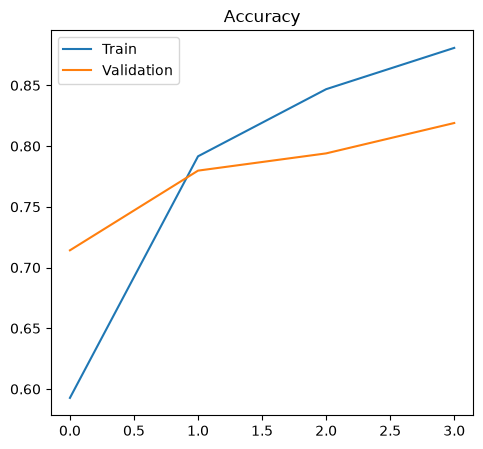

In [22]:
#training and validation accuracy both should be increasing 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

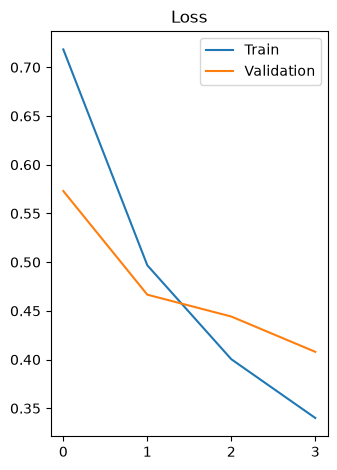

In [23]:
#loss should be decreasing for both training and validation loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
#Evaluate
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print(test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8261 - loss: 0.3981
0.8260800242424011


In [25]:
#predict probabilities
predictions = model.predict(X_test[:5])

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
[[0.7489442]
 [0.9820639]
 [0.831696 ]
 [0.628829 ]
 [0.9838778]]


In [26]:
#Predictions
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step


In [27]:
#valuate with Classification Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step
[[ 9678  2822]
 [ 1526 10974]]
              precision    recall  f1-score   support

           0       0.86      0.77      0.82     12500
           1       0.80      0.88      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000

